## Parameter testing on Total Deep Variation

In [7]:
# Library
import os
import sys
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path: sys.path.append(root_path)
import imageio
import numpy as np
import torch
import model
import matplotlib.pyplot as plt
from denoise import psnr, apply_vn

In [18]:
def check_color(raw_image):
    y = None
    color = None
    if raw_image.ndim == 2: 
        color = "gray"
        y = np.mean(raw_image, 2, keepdims=True)
    else: 
        color = "color"
        y = raw_image[:, :, :3] # chop down 3 channels

    return y, color

def test_img(img_path, sigma, add_noise=True, noisy_img_path=None):
    if add_noise:
        img = imageio.imread(img_path).astype(np.float32) / 255
        y, color = check_color(img)
        z = y + sigma / 255. * np.random.randn(*y.shape).astype(np.float32)

    else:
        noisy_img = imageio.imread(noisy_img_path).astype(np.float32) / 255
        z, color = check_color(noisy_img)
        y = None # no ground truth img

    # load the model state dict
    checkpoint = torch.load(os.path.join('..', 'checkpoints', f'tdv3-3-25-f32-{color}.pth'), map_location=torch.device('cpu'))
    sigma_ref = 25

    # get the variational network with the TDV regularizer
    vn = model.VNet(checkpoint['config'], efficient=False)
    vn.load_state_dict(checkpoint['model'])

    # push the images to torch
    y_th = torch.from_numpy(np.transpose(y, (2,0,1))[None])
    z_th = torch.from_numpy(np.transpose(z, (2,0,1))[None])

    with torch.no_grad():
        x_th = apply_vn(z_th, z_th, vn, sigma, sigma_ref)
    x_S = np.transpose(x_th[-1][0].cpu().numpy(), (1,2,0))

    return z, x_S, y

In [19]:
def plot_results(z, x_S, y=None):
    """
    z: noisy image
    x_S: denoised image
    y: ground truth
    """

    if y is not None:
        # Case with ground truth
        fig, ax = plt.subplots(1, 3, sharex=True, sharey=True)
        ax[0].imshow(z.squeeze(), vmin=0, vmax=1, cmap='gray')
        ax[0].set_title('z')
        ax[0].set_xlabel(f'PSNR={psnr(z,y):.2f}dB')
        ax[1].imshow(x_S.squeeze(), vmin=0, vmax=1, cmap='gray')
        ax[1].set_title('x_S')
        ax[1].set_xlabel(f'PSNR={psnr(x_S,y):.2f}dB')
        ax[2].imshow(y.squeeze(), vmin=0, vmax=1, cmap='gray')
        ax[2].set_title('y')

    else:
        # Case without ground truth
        fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
        ax[0].imshow(z.squeeze(), vmin=0, vmax=1, cmap='gray')
        ax[0].set_title('Noisy')
        ax[1].imshow(x_S.squeeze(), vmin=0, vmax=1, cmap='gray')
        ax[1].set_title('Denoised')

    plt.show()


C:\Users\Paul\AppData\Local\Temp\ipykernel_33504\593901445.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path).astype(np.float32) / 255
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25305757..1.3889424].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0006058863..1.0681282].


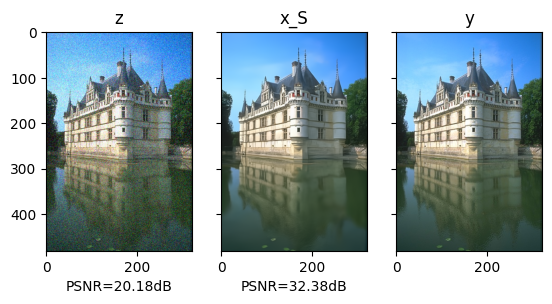

In [20]:
# Test on one img
img_path = os.path.join('..', 'data', 'water-castle.png')
z, x, y = test_img(img_path, sigma= 25)
plot_results(z, x, y)